<a href="https://colab.research.google.com/github/sangimounikayadav/Identifying-a-person-using-audio-aesthetics/blob/main/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/


mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json


chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d vjcalling/speaker-recognition-audio-dataset

Dataset URL: https://www.kaggle.com/datasets/vjcalling/speaker-recognition-audio-dataset
License(s): unknown
100% 3.64G/3.64G [03:50<00:00, 16.6MB/s]
100% 3.64G/3.64G [03:50<00:00, 17.0MB/s]


In [ ]:

! unzip speaker-recognition-audio-dataset.zip

Archive:  speaker-recognition-audio-dataset.zip
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_000.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_001.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_002.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_003.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_004.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_005.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_006.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_007.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_008.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_009.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_010.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_011.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_012.wav  
  inflating: 50_speakers_audio_data/Speaker0026/Speaker26_013.wav  


In [ ]:
!pip install fast_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
import os


import numpy as np
import pandas as pd
import seaborn as sns
import librosa

import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from fast_ml.model_development import train_valid_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [ ]:
DATASET_PATH = "/content/"
PATH = os.path.join(DATASET_PATH, "50_speakers_audio_data")

In [ ]:
data = []

for i, subdir in enumerate(os.listdir(PATH)):
    if (subdir[-2:] != 'ta'):
        for i, file in enumerate(os.listdir(os.path.join(PATH, subdir))):
            data.append([os.path.join(PATH,subdir,file), ("Speaker_" + subdir[-2:])])

In [ ]:
data = pd.DataFrame(data, columns=["File", "Label"])
data["Sets"] = "Training"
print(data.head())

                                                File       Label      Sets
0  /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
1  /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
2  /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
3  /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
4  /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training


In [ ]:
for lbl in data.Label.unique():
    temp_data = data[data["Label"] == lbl]

    X_train, y_train, X_val, y_val, X_test, y_test = train_valid_test_split(temp_data, target="Label", train_size=0.6, valid_size=0.1, test_size=0.3)

    data.Sets.iloc[X_test.index] = "Testing"
    data.Sets.iloc[X_val.index] = "Validation"

In [ ]:
print(len(data))

2511


In [ ]:
def feature_extraction(files):
    y, sr = librosa.load(files.File)

    mfcc_stanley = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=39, dct_type=2).T, axis=0)
    mfcc_htk = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=39, dct_type=3).T, axis=0)

    stft = np.abs(librosa.stft(y))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T,axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T,axis=0)

    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sr).T,axis=0)
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y),sr=sr).T,axis=0)

    Label = files.Label
    Sets = files.Sets

    return mfcc_stanley, mfcc_htk, chroma, mel, contrast, tonnetz, Label, Sets

In [ ]:
data=data[:1000]
print(data)

                                                  File       Label      Sets
0    /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
1    /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10   Testing
2    /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10   Testing
3    /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
4    /content/50_speakers_audio_data/Speaker_0010/S...  Speaker_10  Training
..                                                 ...         ...       ...
995  /content/50_speakers_audio_data/Speaker0028/Sp...  Speaker_28  Training
996  /content/50_speakers_audio_data/Speaker0028/Sp...  Speaker_28  Training
997  /content/50_speakers_audio_data/Speaker0028/Sp...  Speaker_28   Testing
998  /content/50_speakers_audio_data/Speaker0028/Sp...  Speaker_28  Training
999  /content/50_speakers_audio_data/Speaker0048/Sp...  Speaker_48  Training

[1000 rows x 3 columns]


In [ ]:
audio = data.apply(feature_extraction, axis=1)

In [ ]:
def get_feature(data_audio):
    features = []
    labels = []
    sets = []

    for i in range(0, len(data_audio)):
        features.append(np.concatenate((data_audio.iloc[i][0], data_audio.iloc[i][1],
                        data_audio.iloc[i][2], data_audio.iloc[i][3],
                        data_audio.iloc[i][4], data_audio.iloc[i][5]), axis=0))
        labels.append(data_audio.iloc[i][6])
        sets.append(data_audio.iloc[i][7])

    return np.array(features), labels, sets

In [ ]:
X, Label, Sets = get_feature(audio)

In [ ]:
audio = pd.DataFrame(X)
audio["Label"] = Label
audio["Sets"] = Sets

In [ ]:
audio.to_csv("audio.csv", index=False)
data.to_csv("data.csv", index=False)

In [ ]:
X_train = audio[audio["Sets"] == "Training"]
X_test = audio[audio["Sets"] == "Testing"]
X_val = audio[audio["Sets"] == "Validation"]

X_train = X_train.drop(["Label","Sets"], axis=1)
X_test = X_test.drop(["Label","Sets"], axis=1)
X_val = X_val.drop(["Label","Sets"], axis=1)

y_train = audio[audio["Sets"] == "Training"].Label
y_test = audio[audio["Sets"] == "Testing"].Label
y_val = audio[audio["Sets"] == "Validation"].Label

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(594, 231)
(310, 231)
(96, 231)


In [ ]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(594,)
(310,)
(96,)


In [ ]:
num_feature = len(X_train.T)
print(num_feature)

231


In [ ]:
le = LabelEncoder()
le.fit(data["Label"])

LabelEncoder()

In [ ]:
y_train = to_categorical(le.transform(y_train))
y_test = to_categorical(le.transform(y_test))
y_val = to_categorical(le.transform(y_val))

In [ ]:
print(len(y_train[1]))

19


In [ ]:
num_classes = len(y_train[1])

In [ ]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_val = ss.transform(X_val)
X_test = ss.transform(X_test)

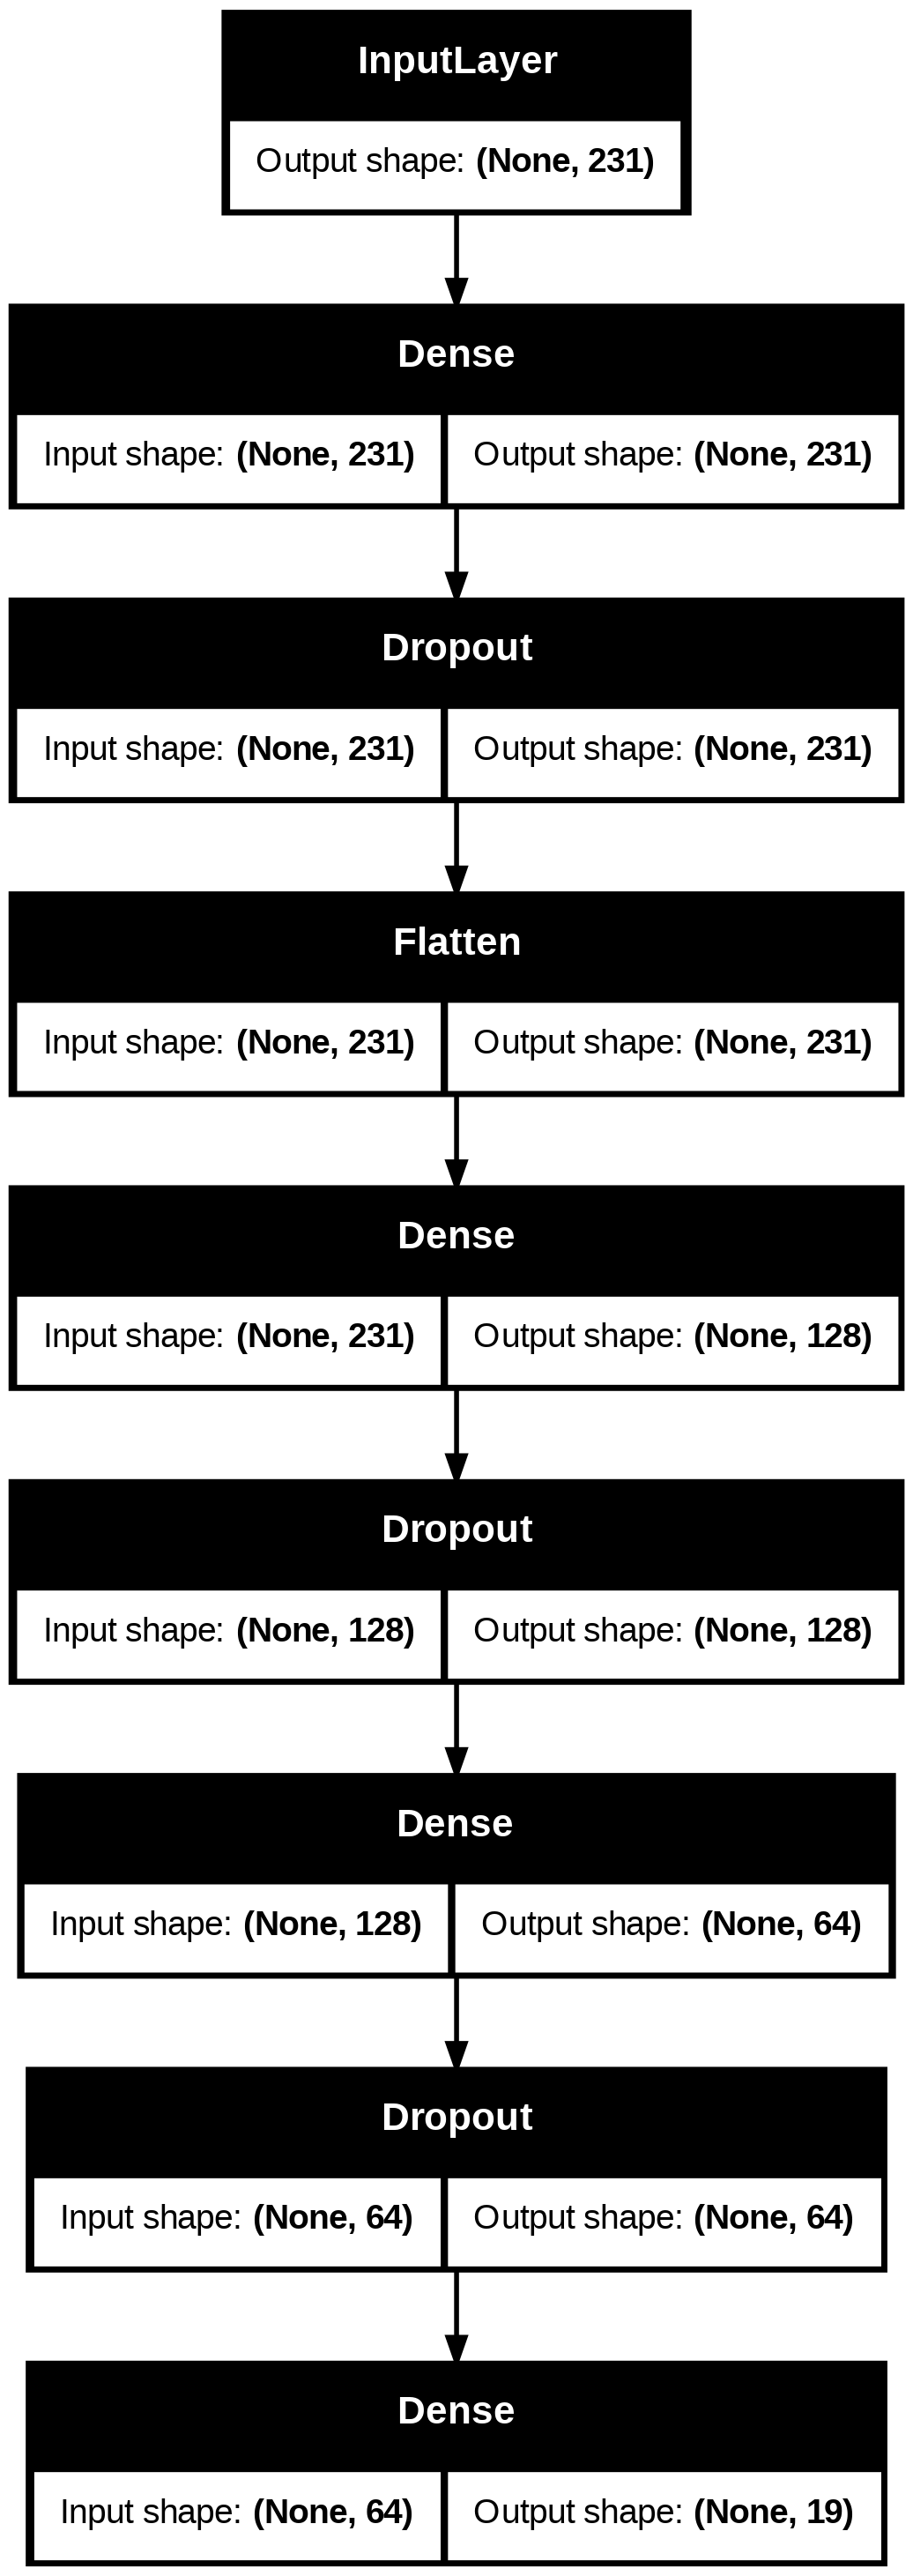

In [ ]:
def make_model(num_feature, num_classes):
    input_layer = keras.layers.Input((num_feature,))

    x = keras.layers.Dense(num_feature, activation='relu')(input_layer)
    x = keras.layers.Dropout(0.1)(x)

    x = keras.layers.Flatten()(x)

    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.25)(x)

    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.5)(x)

    output_layer = keras.layers.Dense(num_classes, activation='softmax')(x)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

model = make_model(num_feature=num_feature, num_classes=num_classes)
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=100, verbose=1, mode='auto'),
]

model.compile(loss=['categorical_crossentropy'],
              metrics=['accuracy', "categorical_accuracy"],
              optimizer='adam')

In [ ]:
epochs = 200
batch_size = 16

with tf.device('/device:GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks
    )

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.2120 - categorical_accuracy: 0.2120 - loss: 2.6727 - val_accuracy: 0.9271 - val_categorical_accuracy: 0.9271 - val_loss: 0.7967 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7112 - categorical_accuracy: 0.7112 - loss: 1.0289 - val_accuracy: 0.9792 - val_categorical_accuracy: 0.9792 - val_loss: 0.1747 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8666 - categorical_accuracy: 0.8666 - loss: 0.5038 - val_accuracy: 0.9792 - val_categorical_accuracy: 0.9792 - val_loss: 0.1122 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9141 - categorical_accuracy: 0.9141 - loss: 0.3531 - val_accuracy: 0.9792 - val_categorical_accuracy: 0.9792 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9711 - categorical_accuracy: 0.9711 - loss: 0.1855 - val_accuracy

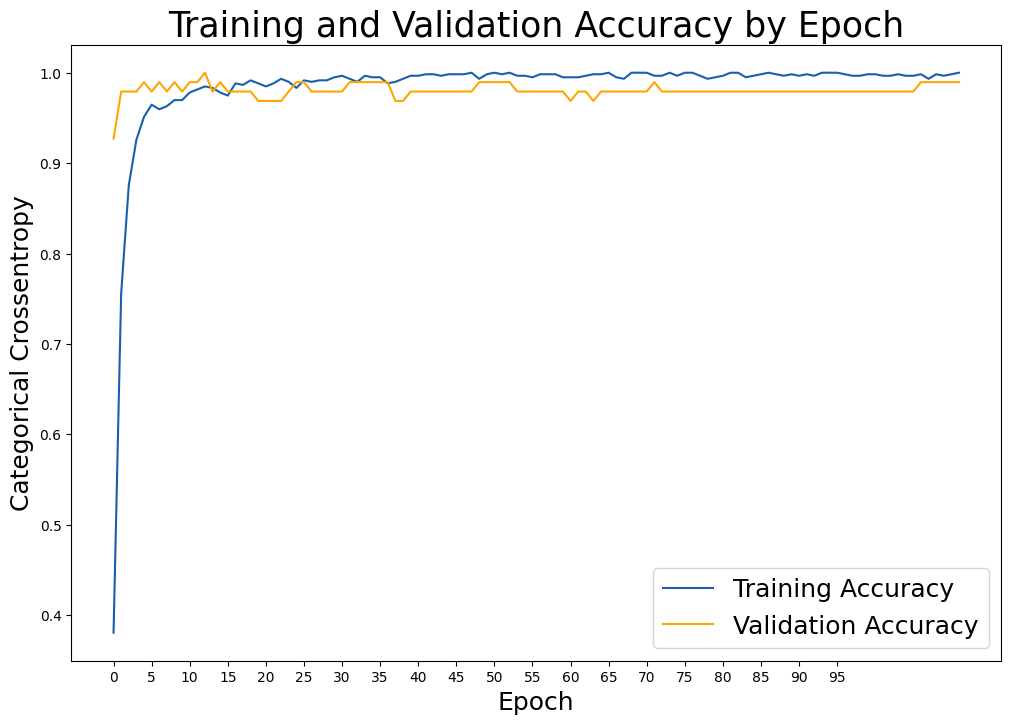

In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(12, 8))

plt.plot(train_accuracy, label='Training Accuracy', color='#185fad')
plt.plot(val_accuracy, label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy by Epoch', fontsize = 25)
plt.xlabel('Epoch', fontsize = 18)
plt.ylabel('Categorical Crossentropy', fontsize = 18)
plt.xticks(range(0,100,5), range(0,100,5))

plt.legend(fontsize = 18);

In [ ]:
y_pred = np.argmax(model.predict(X_test),axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [ ]:
y_pred = le.inverse_transform(y_pred)

In [ ]:
y_actual = le.inverse_transform(np.argmax(y_test, axis=1))

In [ ]:
clf_report = classification_report(y_actual,
                                   y_pred,
                                   output_dict=True)

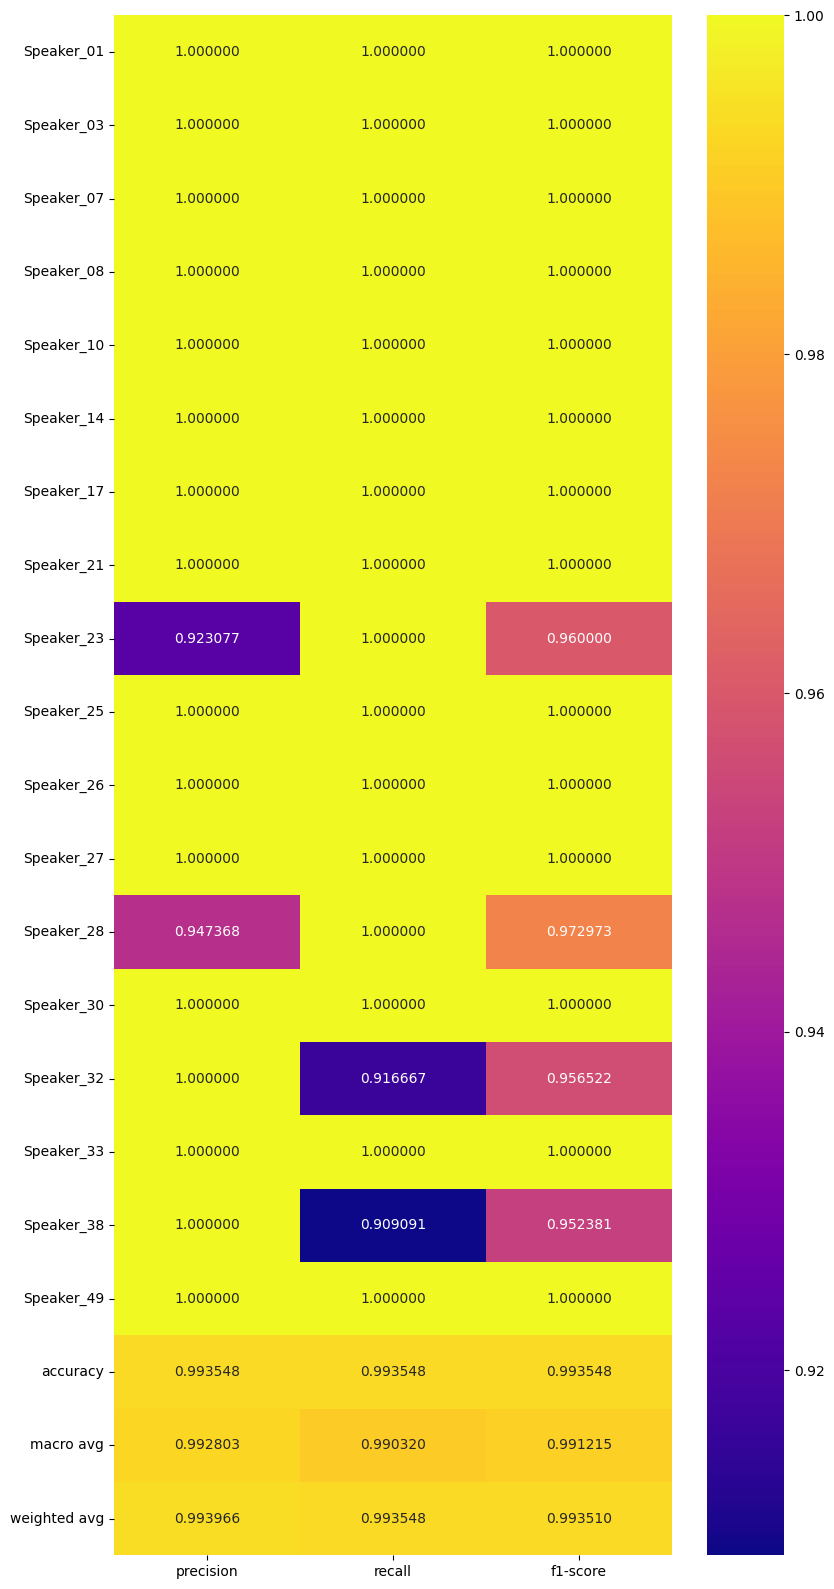

In [ ]:
fig, ax = plt.subplots(figsize=(9, 20))
ax = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True, cmap='plasma', fmt=".6f")